# Prac 07.2

In this homework you are going to inspect the GTSDB (German Traffic Sign Detection Benchmark) dataset. The dataset contains images of various classes of traffic signs used in Germany (and the whole EU). The objective of this homework is to go through the steps described below and to implement the necessary code.

At the end, as usual, there will be a couple of questions for you to answer. In addition, the last section of this homework is optional and, if you chose to do it, you'll earn extra point :-)

In [4]:
import os
import cv2
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

### Step 0

Go to the GTSRB dataset official site ([link](https://benchmark.ini.rub.de/gtsrb_dataset.html)) to learn more about the dataset.

### Step 1

Download the dataset ([link](https://www.kaggle.com/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign)) and unzip it.

### Step 2

For this homework, you will be working with the training set. Check out the `Train.csv`, open it and see what it contains. Load the dataset and plot random samples.

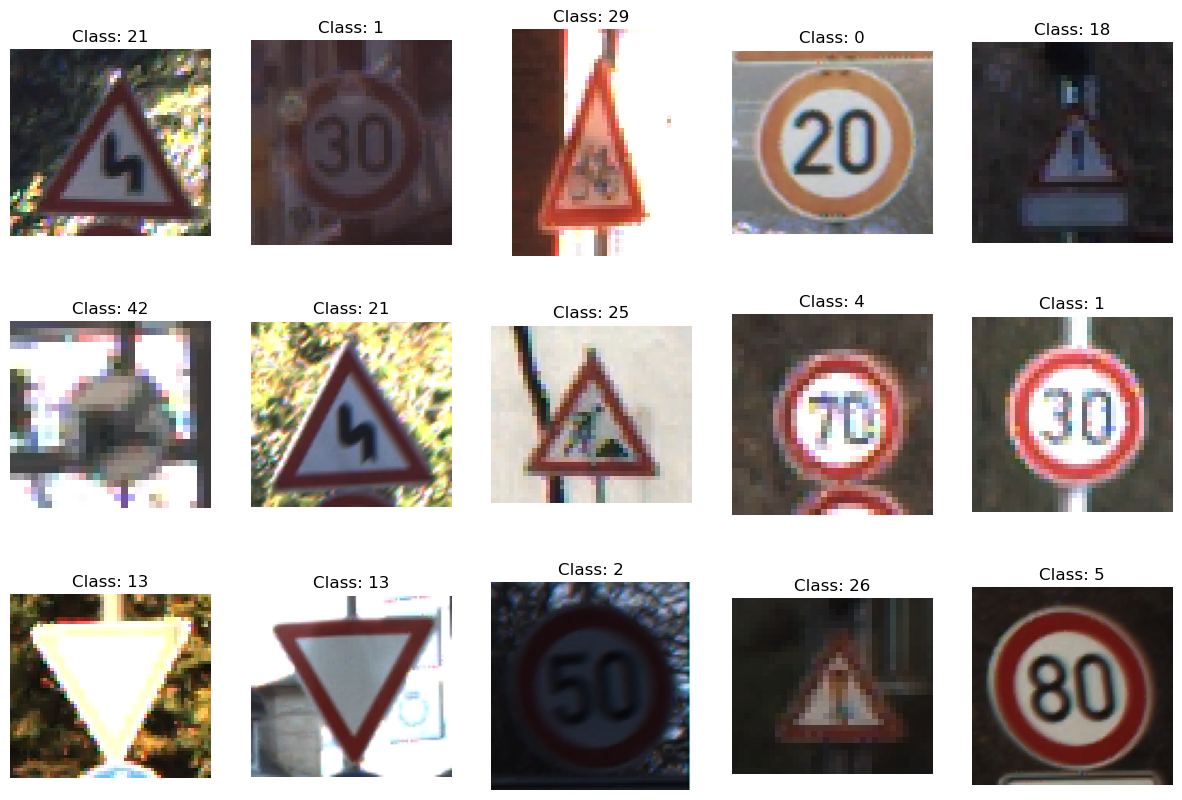

In [8]:
# Load the training labels
root = '../archive'
data = pd.read_csv(os.path.join(root, 'Train.csv'))

# Number of training samples (amount of samples in data)
num_samples = len(data)

# Show random data samples
for ii in range(15):
    # Get random index
    idx = np.random.randint(0, num_samples)
    
    # Load image
    img_path = os.path.join(root, data.iloc[idx]['Path'])
    img = cv2.imread(img_path)
    
    # Convert image to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Show image
    plt.subplot(3, 5, ii + 1)
    plt.imshow(img)
    plt.title(f"Class: {data.iloc[idx]['ClassId']}")
    plt.axis('off')

### Step 3

Inspect the dataset by computing and plotting the per-class histogram.

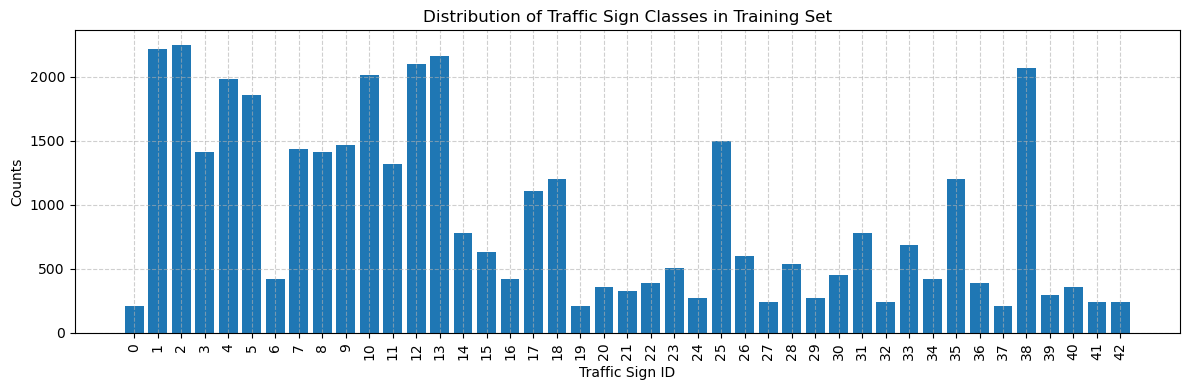

In [12]:
import matplotlib.pyplot as plt
from collections import Counter

ids = data['ClassId'].values
hist = Counter(ids)

plt.figure(figsize=(12,4))
ticks = sorted(hist.keys())
plt.bar(ticks, [hist[k] for k in ticks])
plt.xticks(ticks, ticks, rotation=90)
plt.grid(True, linestyle='--', alpha=0.6)
plt.title('Distribution of Traffic Sign Classes in Training Set')
plt.xlabel('Traffic Sign ID')
plt.ylabel('Counts')
plt.tight_layout()
plt.show()


Compute the per class histogram. You can use any approach you want (e.g. `numpy`). It's also worth looking at the `Counter` function from the `collections` module ([link](https://docs.python.org/3/library/collections.html#collections.Counter)) ;-)

(Text(0.5, 0, 'Traffic Sign ID'), Text(0, 0.5, 'Counts'))

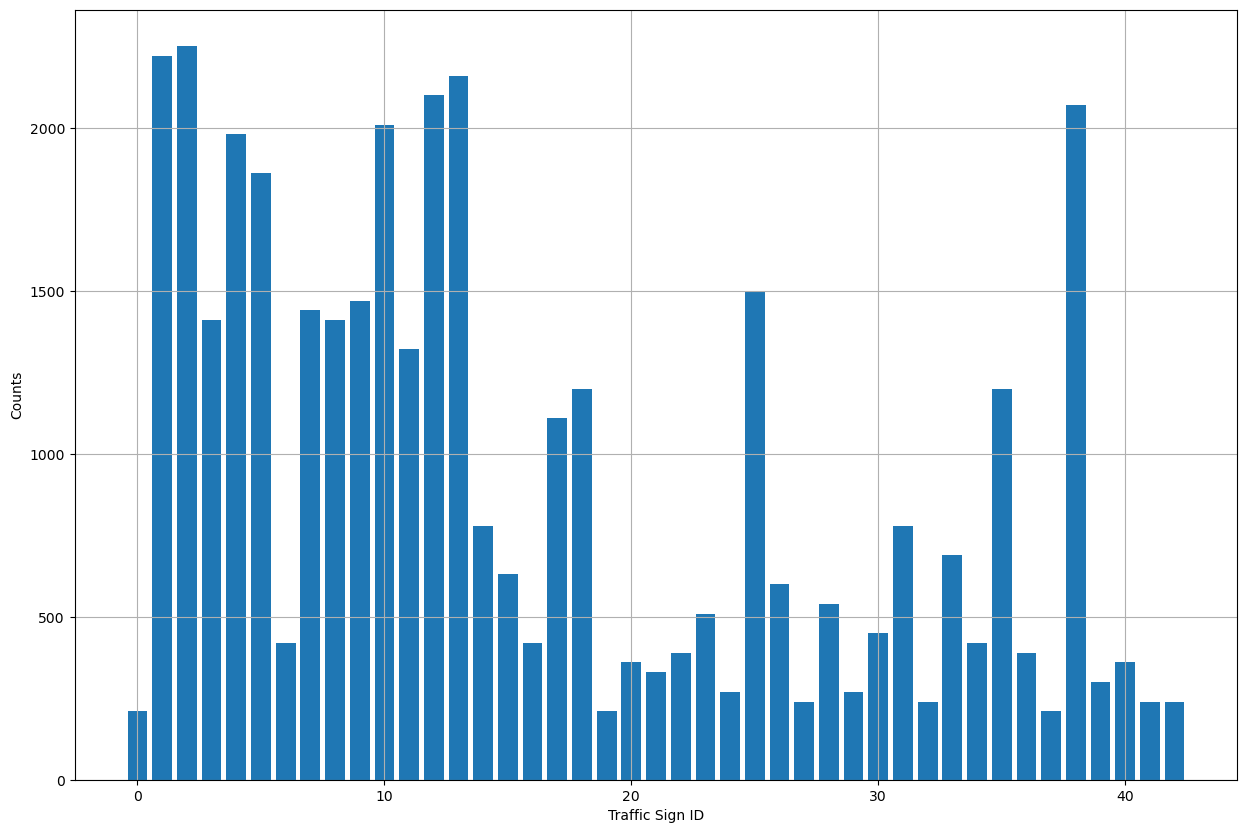

In [10]:
from collections import Counter
hist = Counter(ids)

plt.bar(hist.keys(), hist.values()), plt.grid(True)
plt.xlabel('Traffic Sign ID'), plt.ylabel('Counts')

### Questions

Please answer the following questions:
* Do you consider the dataset to be balanced? If so, why? If not, why?
    - No, the GTSRB dataset is highly imbalanced. When plot the histogram, there will noticed significant variance between the heights of the bars. In real-world driving, certain signs appear far more frequently than others, and the training data reflects this natural frequency.
* Are there any classes that are (significantly) over-represented or under-represeneted?
    - 1, 2, 10, 12, 13, and 38 are significantly over-represented. 0, 19, 24, 27, 32, 37, 41, and 42 are significantly under-represented, with counts falling below 300 samples each

### Optional

Perform a further analysis on the dataset and draw some conclusion from it.

Hint 1: Unlike MNIST or CIFAR10, this dataset contains images with various spatial resolutions. Is there anything we can tell about the resolution distribution?
Hint 2: What about the brightness distribution? Are there classes there are significantly more bright than others?

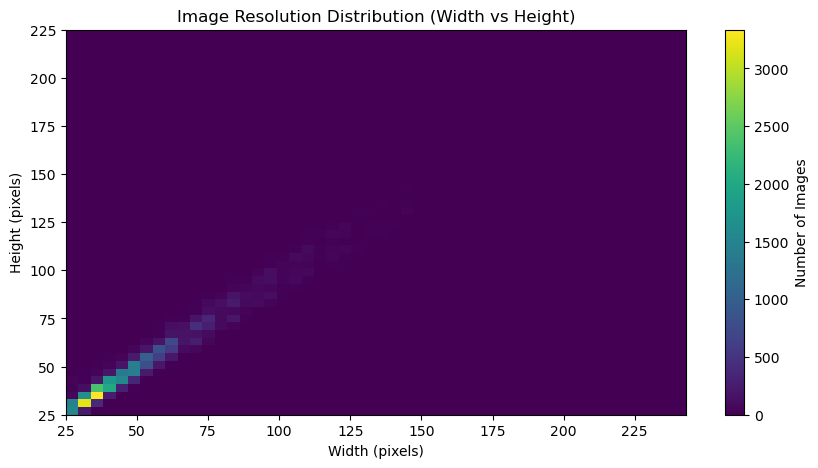

Minimum Resolution: 25x25
Maximum Resolution: 243x225


In [13]:
plt.figure(figsize=(10, 5))
plt.hist2d(data['Width'], data['Height'], bins=50, cmap='viridis')
plt.colorbar(label='Number of Images')
plt.title('Image Resolution Distribution (Width vs Height)')
plt.xlabel('Width (pixels)')
plt.ylabel('Height (pixels)')
plt.show()

print(f"Minimum Resolution: {data['Width'].min()}x{data['Height'].min()}")
print(f"Maximum Resolution: {data['Width'].max()}x{data['Height'].max()}")

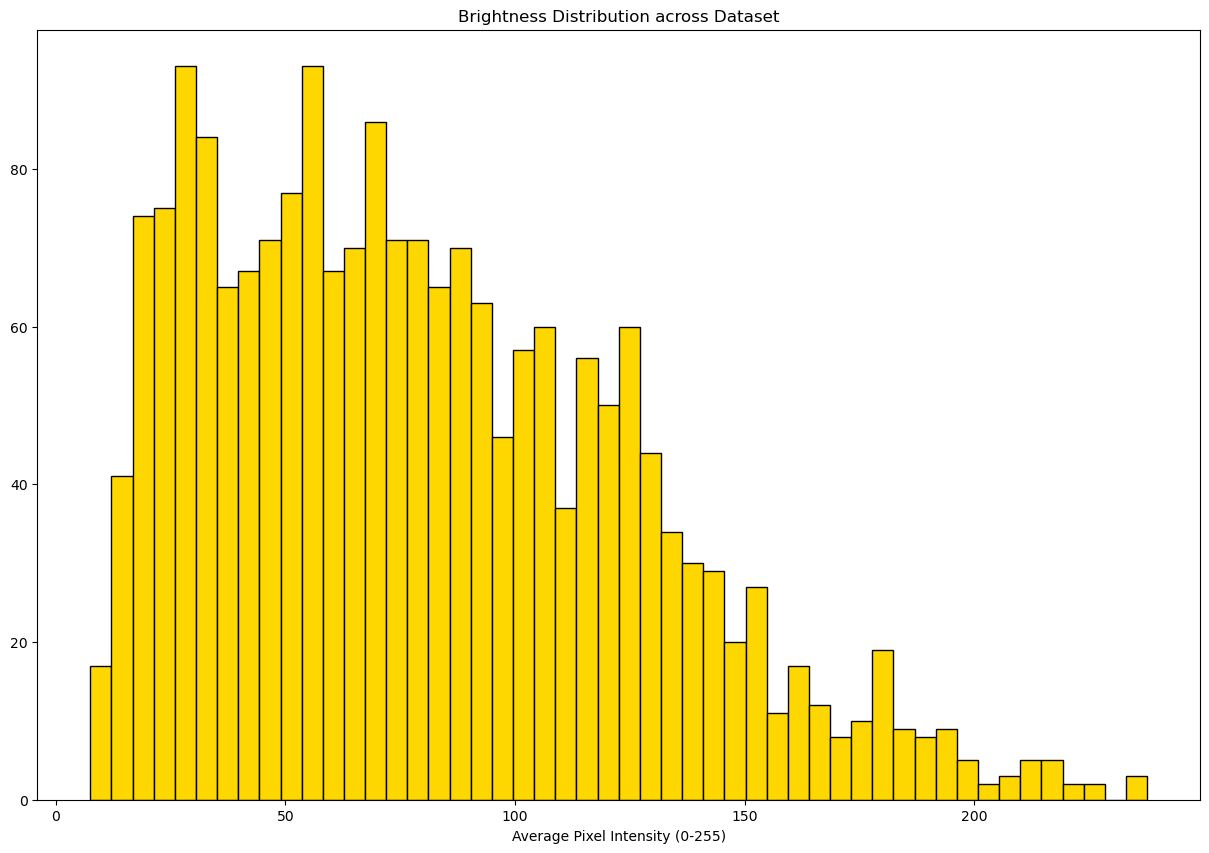

In [14]:
sample_data = data.sample(2000)
brightness_values = []

for _, row in sample_data.iterrows():
    img = cv2.imread(os.path.join(root, row['Path']), cv2.IMREAD_GRAYSCALE)
    brightness_values.append(np.mean(img))

plt.hist(brightness_values, bins=50, color='gold', edgecolor='black')
plt.title('Brightness Distribution across Dataset')
plt.xlabel('Average Pixel Intensity (0-255)')
plt.show()

Calculating brightness for each image...


/var/folders/z7/cb_2lss97zj2gmz4r6jxs6km0000gn/T/ipykernel_23213/1032111941.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='ClassId', y='Brightness', data=data, palette='viridis')


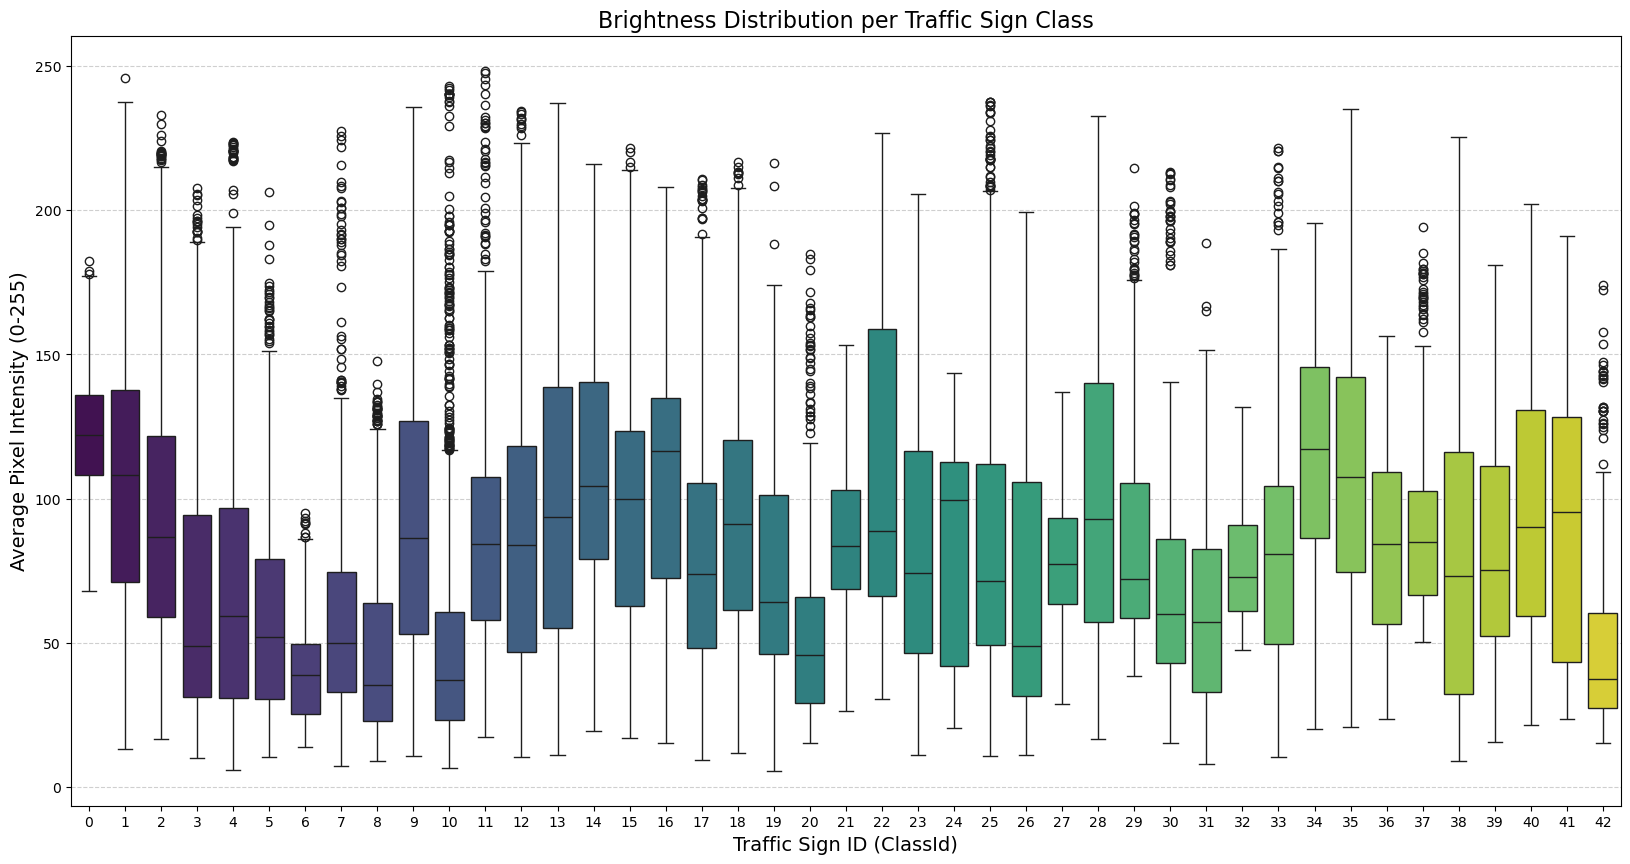


Top 5 Darkest Classes (Average):
ClassId
6     39.763298
8     46.417241
10    49.897578
42    51.546390
20    56.886144
Name: Brightness, dtype: float64

Top 5 Brightest Classes (Average):
ClassId
22    109.308372
14    109.669696
34    112.877179
35    113.076713
0     122.217519
Name: Brightness, dtype: float64


In [ ]:
import seaborn as sns
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

brightness_values = []

print("Calculating brightness for each image...")
for index, row in data.iterrows():
    img_path = os.path.join(root, row['Path'])

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    
    if img is not None:
        brightness_values.append(np.mean(img))
    else:
        brightness_values.append(np.nan)

data['Brightness'] = brightness_values

plt.figure(figsize=(20, 10))
sns.boxplot(x='ClassId', y='Brightness', data=data, palette='viridis')

plt.title('Brightness Distribution per Traffic Sign Class', fontsize=16)
plt.xlabel('Traffic Sign ID (ClassId)', fontsize=14)
plt.ylabel('Average Pixel Intensity (0-255)', fontsize=14)
plt.grid(True, axis='y', linestyle='--', alpha=0.6)

plt.show()

stats = data.groupby('ClassId')['Brightness'].mean().sort_values()
print("\nTop 5 Darkest Classes (Average):")
print(stats.head(5))

print("\nTop 5 Brightest Classes (Average):")
print(stats.tail(5))